# Measures of Dispersion
## Variance and Standard Deviation

> **Disclaimer:** This notebook was generated with the assistance of AI and has been human-reviewed for accuracy and quality.

**Topics Covered:**
- Measures of Dispersion
- Variance
- Standard deviation 
- Matplotlib
- Interpreting dispersion in data visualizations

## 1. Measures of Dispersion

Measures of dispersion describe **how spread out** the values in a dataset are. Two datasets can share the same mean but look completely different depending on their spread.

---

### Population vs. Sample

A **population** is the entire group you are studying. A **sample** is a smaller subset drawn from that population.

This distinction matters when computing variance and standard deviation:

- **Population** — you have *all* the data, so you divide by **N** (the total count).
- **Sample** — you only have *part* of the data, so you divide by **N − 1** to correct for the fact that a sample tends to underestimate the true spread.

| | Population | Sample |
|---|---|---|
| Variance | `statistics.pvariance(data)` | `statistics.variance(data)` |
| Std Dev | `statistics.pstdev(data)` | `statistics.stdev(data)` |

> In practice, you are almost always working with a **sample**, so `statistics.variance` and `statistics.stdev` are the default choice.

---

### Variance
The average of the **squared differences** from the mean. Squaring ensures all differences are positive and gives extra weight to values far from the mean.

---

### Standard Deviation
The **square root of the variance**, bringing the unit back to the same scale as the original data. It is the most commonly used measure of spread.

---

### Range
The simplest measure — the **difference between the maximum and minimum** values. Easy to compute but sensitive to outliers.

```python
range_ = max(data) - min(data)
```

---

### Interquartile Range (IQR)
The spread of the **middle 50%** of the data (Q3 − Q1). More robust than range because it ignores extreme values.

```python
import statistics
q1 = statistics.quantiles(data, n=4)[0]   # 25th percentile
q3 = statistics.quantiles(data, n=4)[2]   # 75th percentile
iqr = q3 - q1
```

---

> **Rule of thumb:** A small standard deviation means values are tightly packed around the mean. A large one means they are widely scattered.

## Matplotlib Refresher

Reminder: we can create data visualizations simply by calling the `plt` package and then specifying what kind of visualization we want.

We namely do this by creating a `fig` and `ax` object from `plt.subplots()` and then pass a list of data to a method attached to the `ax` object.

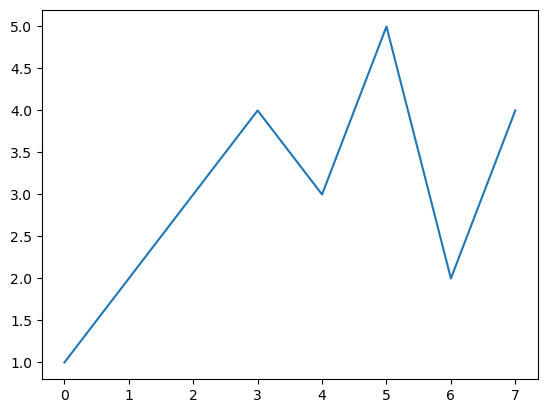

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot([1, 2, 3, 4, 3, 5, 2, 4])
plt.show()

However, we can also simply use the `plt` package name to create visualizations. This is what we call the "implicit" method of using matplotlib.

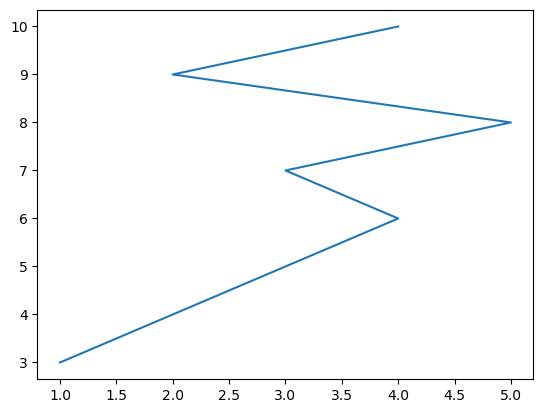

In [16]:
plt.plot([1, 2, 3, 4, 3, 5, 2, 4], [3,4,5,6,7,8,9,10])

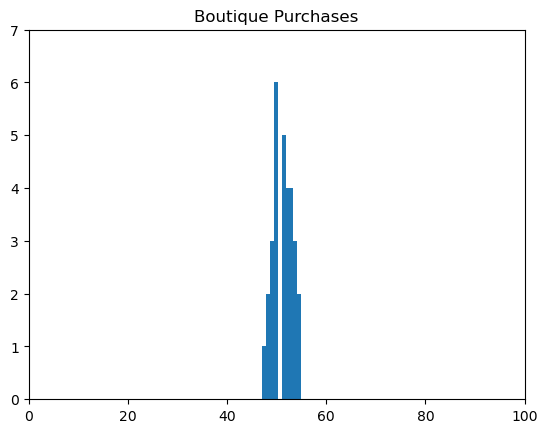

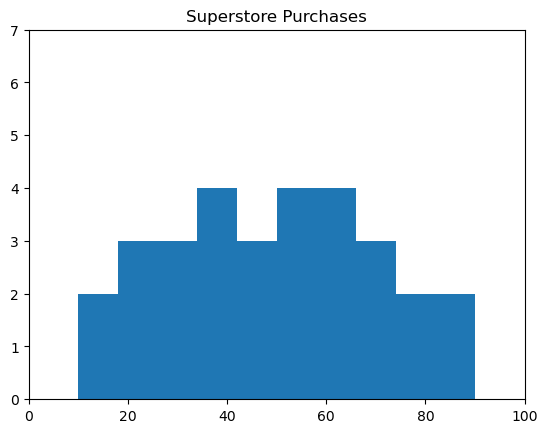

In [30]:
import matplotlib.pyplot as plt
import statistics as stat

# Purchase amounts ($) at a small boutique online store
boutique_store = [47, 48, 48, 49, 49, 49, 50, 50, 50, 50, 50, 50, 51, 51, 51, 51, 51, 52, 52, 52, 52, 53, 53, 53, 53, 54, 54, 54, 55, 55]

# Purchase amounts ($) at a large online retailer
superstore = [10, 15, 18, 22, 25, 27, 30, 33, 35, 37, 39, 41, 43, 45, 47, 50, 53, 55, 57, 59, 61, 63, 65, 67, 70, 73, 75, 78, 82, 90]

plt.figure()
plt.hist(boutique_store)
# modify the x and y axis of our plots
plt.xlim(0, 100)
plt.ylim(0, 7)
# give a title to our plot
plt.title("Boutique Purchases")
plt.show()

plt.figure()
plt.hist(superstore)
# modify the x and y axis of our plots
plt.xlim(0, 100)
plt.ylim(0, 7)
# give a title to our plot
plt.title("Superstore Purchases")
plt.show()

In [18]:
# how can I calculate the avg of boutique_store list
stat.mean(boutique_store)

51.233333333333334

In [19]:
# how can I calculate the avg of superstore list
stat.mean(superstore)

48.833333333333336

In [20]:
boutique_variance = stat.variance(boutique_store)
print("boutique variance:", round(boutique_variance, 1))

boutique variance: 4.5


In [21]:
# TODO: calculate superstore variance 
superstore_variance = stat.variance(superstore)

print("superstore variance:", round(superstore_variance, 1))


superstore variance: 449.8


## 2. Interquartile Range (IQR)

### What problem does IQR solve?

Range is a good metric to understand the expected values of our dataset, but it is sensitive to **outliers** — extreme values that sit far from the rest of the data. A single unusually large purchase (say, a customer who spent $500 on a bulk order) can inflate the range and make a dataset look much more spread out than it really is for a typical customer.

The **IQR** fixes this by ignoring the top and bottom 25% of values entirely and measuring only the spread of the **middle 50%**.

To find the IQR:
1. Find **Q1** — the value at the 25th percentile (bottom quarter)
2. Find **Q3** — the value at the 75th percentile (top quarter)
3. **IQR = Q3 − Q1**

This means a $500 outlier purchase has zero effect on the IQR, making it a much more reliable measure of what a *typical* customer spends.

> **In data analytics**, IQR is commonly used to detect and filter outliers. A value is often flagged as an outlier if it falls more than **1.5 × IQR** below Q1 or above Q3.

In [22]:
quants_boutique = stat.quantiles(boutique_store, n=4)
quants_super = stat.quantiles(superstore,   n=4)

print(quants_boutique)
print(quants_super)

[50.0, 51.0, 53.0]
[32.25, 48.5, 65.5]


In [23]:
# TODO: how do I get the 3rd quartile & the 1st quartile from my list???
iqr_boutique = quants_boutique[-1] - quants_boutique[0]

iqr_super = quants_super[-1] - quants_super[0]

print("IQR of Boutique Store", iqr_boutique)
print("IQR of Super Store", iqr_super)

IQR of Boutique Store 3.0
IQR of Super Store 33.25


In [24]:
# CHALLENGE: can you use a for-loop to get the outliers of our superstore list
...

## 3. Summation

**Summation** is the process of adding up a collection of values. In math, we use the uppercase Greek letter **sigma** to express this compactly:

$$\sum_{i=1}^{n} x_i$$

Read as: *"add up every value $x_i$, starting at index 1, all the way to index $n$."*

For example, if we have the list `[10, 20, 30]`, the summation gives us:

$$\sum_{i=1}^{3} x_i = 10 + 20 + 30 = 60$$

In Python we can express that same idea using a `for` loop — iterate over every item in the list and keep a running total.

In [25]:
values = [10, 20, 30]

total = 0

# TODO: what is going to be the value of total when we finish iterating through our second value of the list (20)

for x in values:
    total = total + x

print(total)

60


### Squaring the sum vs. summing the squares

These two expressions look similar but produce very different results:

| Expression | Meaning |
|---|---|
| $\left(\sum x\right)^2$ | Add everything up, **then** square the total |
| $\sum x^2$ | Square **each value first**, then add them up |

Using `[10, 20, 30]` as an example:

$$\left(\sum x\right)^2 = (10 + 20 + 30)^2 = 60^2 = 3600$$

$$\sum x^2 = 10^2 + 20^2 + 30^2 = 100 + 400 + 900 = 1400$$

The order of operations changes the answer entirely. This distinction is at the heart of how **variance** is calculated — variance measures how far each individual value is from the mean, so we square *each difference* before summing, not after.

In [26]:
# (sum of x) squared
total = 0
for x in values:
    total = total + x
print("(sum of x) squared:", total ** 2)

(sum of x) squared: 3600


In [27]:
# sum of (x squared)
total_of_squares = 0
for x in values:
    total_of_squares = total_of_squares + x ** 2
    
print("sum of (x squared):", total_of_squares)

sum of (x squared): 1400


## 4. Variance

A retail company tracks how long customers wait in line (in minutes) across 10 visits to two of their store locations:

- **Store A** — a newer location with self-checkout kiosks
- **Store B** — an older location with traditional cashier lanes

The manager notices both stores have the **same average wait time**. But are they really performing the same?

This is exactly the kind of question variance helps us answer. Before we reach for `statistics.variance()`, let's build up to it.

**Think about it:** if you wanted to measure how "inconsistent" the wait times are, what would you do?

One natural approach: find the mean, then look at how far each value is from it. The bigger those differences, the more spread out — or *variable* — the data is.

We call this the **average of the squared differences from the mean**, and it's exactly what variance measures. We'll build it step by step below.

In [28]:
import statistics

store_a = [4,4,4,4,4,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,6,6,6,6,6,6]
store_b = [1,2,3,4,5,5,6,7,8,9,1,2,3,4,5,5,6,7,8,9,1,2,3,4,5,5,6,7,8,9]

# TODO
avg_stora = ...
avg_storb = ...

print("Store A mean:", avg_stora)
print("Store B mean:", avg_storb)


Store A mean: Ellipsis
Store B mean: Ellipsis


Nearly the same mean — but are the stores really equivalent?

Now let's look at the **deviations** — the difference between each value and the mean. We'll do Store A together, then it's your turn for Store B.

In [29]:
deviations_a = []
for x in store_a:
    deviations_a.append(x - avg_stora)

print("Store A deviations:", deviations_a)
print("Store A deviations sum:", sum(deviations_a)) 

TypeError: unsupported operand type(s) for -: 'int' and 'ellipsis'

In [ ]:
# TODO: do the same for store_b
deviations_b = []

...

print("Store B deviations:", deviations_b)
print("Store A deviations sum:", sum(deviations_b)) 

Notice anything strange? If you sum up all the deviations, they cancel out to zero — the positive and negative differences balance each other perfectly. This will always happen, because the mean sits right in the middle of the data by definition.

So summing raw deviations is useless as a measure of spread. The fix: **square each deviation** before summing. Squaring makes every value positive, and it amplifies larger differences so they contribute more weight.

In [ ]:
squared_deviations_a = []
for d in deviations_a:
    squared_deviations_a.append(d ** 2)

print("Store A squared deviations:", squared_deviations_a)

In [ ]:
# TODO: square each deviation in deviations_b
squared_deviations_b = []

...

print("Store B squared deviations:", squared_deviations_b)

### Why square the differences?

Two reasons:

1. **Negatives cancel out.** As we saw, raw deviations always sum to zero. Squaring makes every value positive so differences can actually accumulate.
2. **Larger gaps get more weight.** A deviation of 4 becomes 16 when squared. A deviation of 1 only becomes 1. Squaring punishes values that are far from the mean more heavily.

**But there's a catch — units.**

If our data is in *minutes*, then each deviation is also in minutes. When we square it, the unit becomes **minutes²**. That's not a real unit anyone can intuitively understand.

> What does it mean for a wait time to be *9 minutes squared*?

This is exactly why we don't stop at variance. Taking the **square root** of the variance brings us back to the original unit — minutes — and gives us a number we can actually reason about. That is **standard deviation**.

In [ ]:
import math 

print("Store A standard deviation:", math.sqrt(squared_deviations_a))
print("Store B standard deviation:", math.sqrt(squared_deviations_b))

(0.0, 7.0)

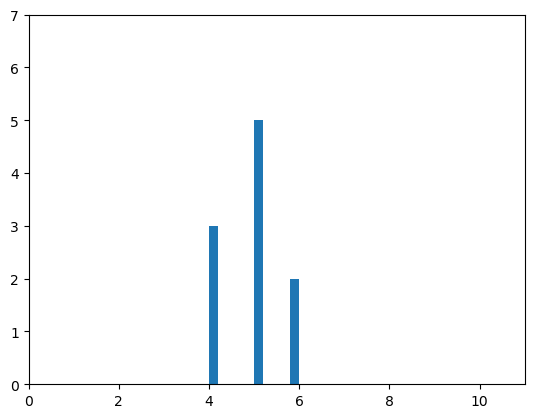

In [ ]:
plt.hist(store_a)
plt.xlim(0, 11)
plt.ylim(0, 7)

(0.0, 7.0)

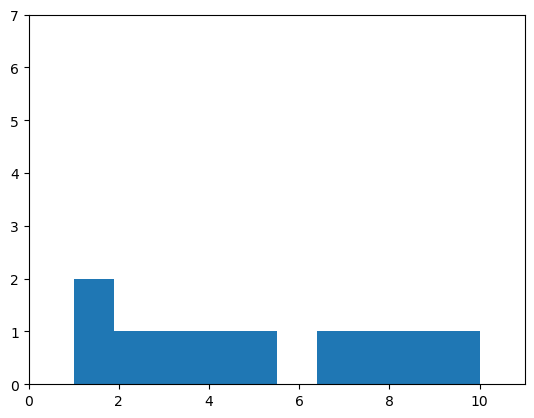

In [ ]:
plt.hist(store_b)
plt.xlim(0, 11)
plt.ylim(0, 7)

## 5. Standard Deviation

Standard deviation is the **square root of the variance**. By taking the square root we undo the squaring from earlier, bringing the measurement back into the original unit — so if our data is in minutes, our standard deviation is also in minutes.

It is the most widely used measure of spread in data analytics because it is:
- **Interpretable** — it lives on the same scale as your data
- **Comparable** — you can use it to compare spread across different datasets
- **Actionable** — it gives you a principled way to flag unusual values

### Spotting outliers with standard deviation

A common rule of thumb: any value that falls more than **2 standard deviations away from the mean** is worth investigating as a potential outlier. In a roughly normal distribution this threshold captures about 95% of expected values, so anything outside it is statistically unusual.

$$\text{outlier if } x < \bar{x} - 2\sigma \quad \text{or} \quad x > \bar{x} + 2\sigma$$

Below we look at 30 days of revenue ($) at a coffee shop. Most days cluster around the same range, but a few stand out — a day the power went out, and a few days with private events that drove unusually high sales.

In [ ]:
daily_revenue = [
    820, 835, 850, 860, 875, 880, 890, 900, 910, 915,
    920, 930, 940, 945, 950, 960, 970, 975, 980, 990,
    1000, 1010, 1025, 1040, 1060, 1080,
    155,           # power outage
    2600, 2900, 3100  # private events
]

# TODO: get mean revenue
mean   = statistics.mean(daily_revenue)
stdev  = statistics.pstdev(daily_revenue)

print("Mean daily revenue: $", mean)
print("Std deviation:      $", stdev)

# detect outliers through some sort of automated/mathematical means

Mean daily revenue: $ 1108.8333333333333
Std deviation:      $ 609.4870566486397


In [33]:
# TODO: which values do we expect within 1 standard deviation
print(mean - stdev)
print(mean + stdev)

499.3462766846935
1718.320389981973


In [34]:
print(mean - (2 * stdev))
print(mean + (2 * stdev))

-110.14077996394622
2327.8074466306125


In [ ]:
outliers = []

# TODO: create a for loop to check for each revenue value
...:
    # TODO: check if value is above 2 standard deviations above the mean
    if ...""
        outliers.append(x)

print("Outliers:", outliers)

C:\Users\saidmf\AppData\Local\Temp\ipykernel_24932\3336274601.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


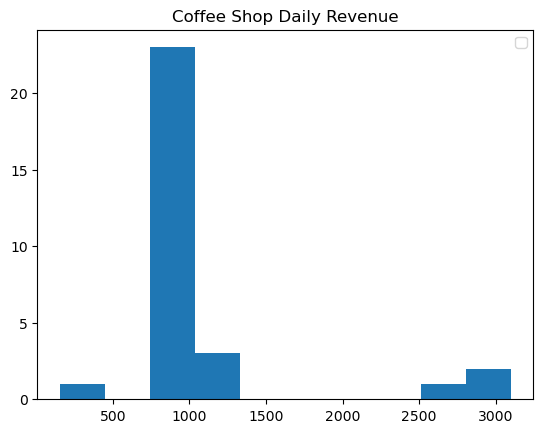

In [ ]:
plt.hist(daily_revenue)
plt.title("Coffee Shop Daily Revenue")
plt.legend()
plt.show()

## 6. Exercise

Below are three datasets collected from different real-world scenarios. For each one, your job is to:

1. Calculate the **mean** and **population standard deviation** using the `statistics` module
2. CHALLENGE: Use the **±2 standard deviation rule** to identify any outliers
3. Write a one-line comment underneath describing your findings — is variance high or low? Are there many outliers or few?

**Datasets:**
- `response_times` — how long (in seconds) a web server took to respond to requests
- `exam_scores` — student scores on a standardized test
- `delivery_days` — number of days it took an e-commerce company to deliver orders

In [ ]:
import statistics
import matplotlib.pyplot as plt

response_times = [
    1.1, 1.2, 1.1, 1.3, 1.2, 1.1, 1.4, 1.2, 1.3, 1.1,
    1.2, 1.3, 1.1, 1.2, 1.4, 1.3, 1.2, 1.1, 1.2, 1.3,
    1.1, 1.2, 1.3, 1.1, 1.4, 1.2, 9.8, 12.4, 0.1, 11.7
]

# TODO: calculate the mean and pstdev
mean = ...
stdev = ...

# CHALLENGE: pull the outliers from this dataset
outliers = []
...

What are your observations on this dataset?



In [ ]:
exam_scores = [
    55, 58, 60, 61, 63, 64, 65, 66, 67, 68,
    69, 70, 71, 72, 73, 74, 75, 76, 77, 78,
    79, 80, 81, 82, 83, 84, 85, 86, 88, 90
]

# TODO: calculate the mean and pstdev
mean = ...
stdev = ...

# CHALLENGE: pull the outliers from this dataset
outliers = []
...

What are your observations on this dataset?



In [ ]:
delivery_days = [
    2, 14, 3, 22, 2, 18, 3, 1, 25, 2,
    3, 19, 2, 3, 21, 2, 3, 2, 17, 3,
    2, 23, 3, 2, 16, 3, 2, 20, 3, 2
]

# TODO: calculate the mean and pstdev
mean = ...
stdev = ...

# CHALLENGE: pull the outliers from this dataset
outliers = []
...

What are your observations on this dataset?

